In [ ]:
import numpy as np

def find_combinations(tensor, threshold):
    m, n = tensor.shape
    row_set = set(range(m))  # Available rows
    col_set = set(range(n))  # Available columns
    combinations = {}  # Store the result

    # Compute valid columns for each row
    row_options = {i: {j for j in col_set if tensor[i, j] < threshold} for i in row_set}

    # Sort rows based on the number of available columns (ascending order)
    sorted_rows = sorted(row_options.keys(), key=lambda x: len(row_options[x]))

    while sorted_rows:
        best_choice = None
        max_covered = 0
        min_sum = float('inf')

        # Find the best row-column combination maximizing row coverage first, then minimizing sum
        for row in sorted_rows:
            valid_cols = row_options[row] & col_set
            if valid_cols:
                for col in valid_cols:
                    temp_col_set = col_set - {col}
                    temp_coverage = sum(1 for r in sorted_rows if row_options[r] & temp_col_set)
                    temp_sum = sum(tensor[r, min(row_options[r] & temp_col_set, key=lambda c: tensor[r, c], default=col)] for r in sorted_rows if row_options[r] & temp_col_set)

                    if temp_coverage > max_covered or (temp_coverage == max_covered and temp_sum < min_sum):
                        best_choice = (row, col)
                        max_covered = temp_coverage
                        min_sum = temp_sum

        if best_choice:
            row, chosen_col = best_choice
            combinations[row] = [chosen_col]
            col_set.remove(chosen_col)
            sorted_rows.remove(row)

            # Re-sort rows after each assignment to prioritize those with fewer options
            sorted_rows = sorted(sorted_rows, key=lambda x: len(row_options[x] & col_set))
        else:
            break

    return {f"A{row+1}": [f"B{col+1}" for col in cols] for row, cols in combinations.items()}


In [ ]:
# Example Usage
tensor = np.array([[4, 3, 7],
                   [2, 8, 5],
                   [4, 3, 9]])
threshold = 6
print(find_combinations(tensor, threshold))

{'A2': ['B3'], 'A1': ['B1'], 'A3': ['B2']}


In [ ]:
tensor = np.array([[4, 3, 7],
                   [2, 4, 3],
                   [1, 7, 4]])
threshold = 5
print(find_combinations(tensor, threshold))

{'A3': ['B3'], 'A1': ['B2'], 'A2': ['B1']}


In [ ]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def compute_and_display_segments(image, k=5, color_space='RGB',image_number=None, initial_centroids=None, seg_return = False):
    # Convert PIL.Image.Image to NumPy array (OpenCV uses BGR format by default)
    image = np.array(image)
    if image.ndim == 2:  # Handle grayscale images
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Ensure the image is in BGR format for OpenCV processing
    if image.shape[-1] == 4:  # Handle RGBA images
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2BGR)
    elif image.shape[-1] == 3 and color_space == 'RGB':
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Convert to specified color space
    if color_space == 'HSV':
        image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    elif color_space == 'Lab':
        image = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    else:  # Default to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Reshape image into 2D array of pixels
    pixels = image.reshape(-1, 3)

    # Apply K-Means clustering
    if initial_centroids is not None:
        kmeans = KMeans(n_clusters=k, init=np.array(initial_centroids), n_init=1, random_state=42)
    else:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

    kmeans.fit(pixels)

    # Get cluster labels and dominant colors
    labels = kmeans.labels_
    dominant_colors = kmeans.cluster_centers_

    # Create segmented images for each cluster
    segmented_images = []
    for cluster_idx in range(k):
        # Create a mask for the current cluster
        mask = (labels == cluster_idx)

        # Initialize a black image
        cluster_image = np.zeros_like(pixels, dtype=np.uint8)

        # Set pixels belonging to the cluster to their original color
        cluster_image[mask] = pixels[mask]

        # Reshape to original dimensions
        cluster_image = cluster_image.reshape(image.shape)
        segmented_images.append(cluster_image)

    # Plot the original image and each segment
    plt.figure(figsize=(15, 8))
    plt.subplot(2, (k + 1) // 2 + 1, 1)
    plt.title(f"Original Image {image_number}")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    for i, segmented in enumerate(segmented_images, start=2):
        plt.subplot(2, (k + 1) // 2 + 1, i)
        plt.title(f"Segment {i - 1}")
        plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.tight_layout()
    # Get dominant colors and proportions
    dominant_colors = kmeans.cluster_centers_
    proportions = np.bincount(kmeans.labels_) / len(kmeans.labels_)

    if seg_return == True:
      return dominant_colors, proportions, segmented_images
    else:
       return dominant_colors, proportions



In [ ]:
from PIL import Image

im1 = Image.open("/content/sunset1.jpg")
im2 = Image.open("/content/sunset2.jpg")


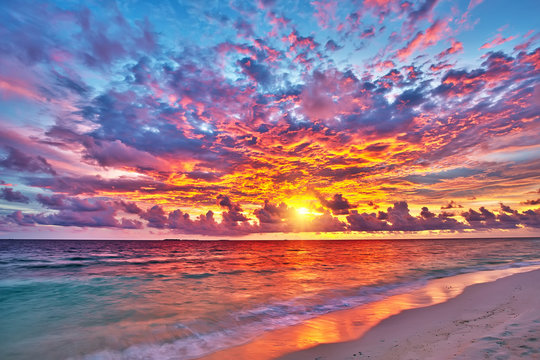

In [ ]:
im1

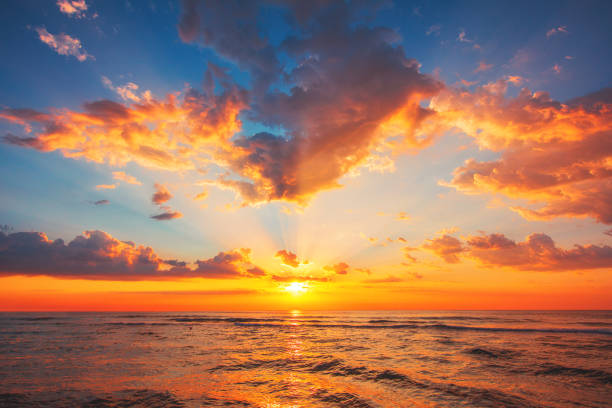

In [ ]:
im2

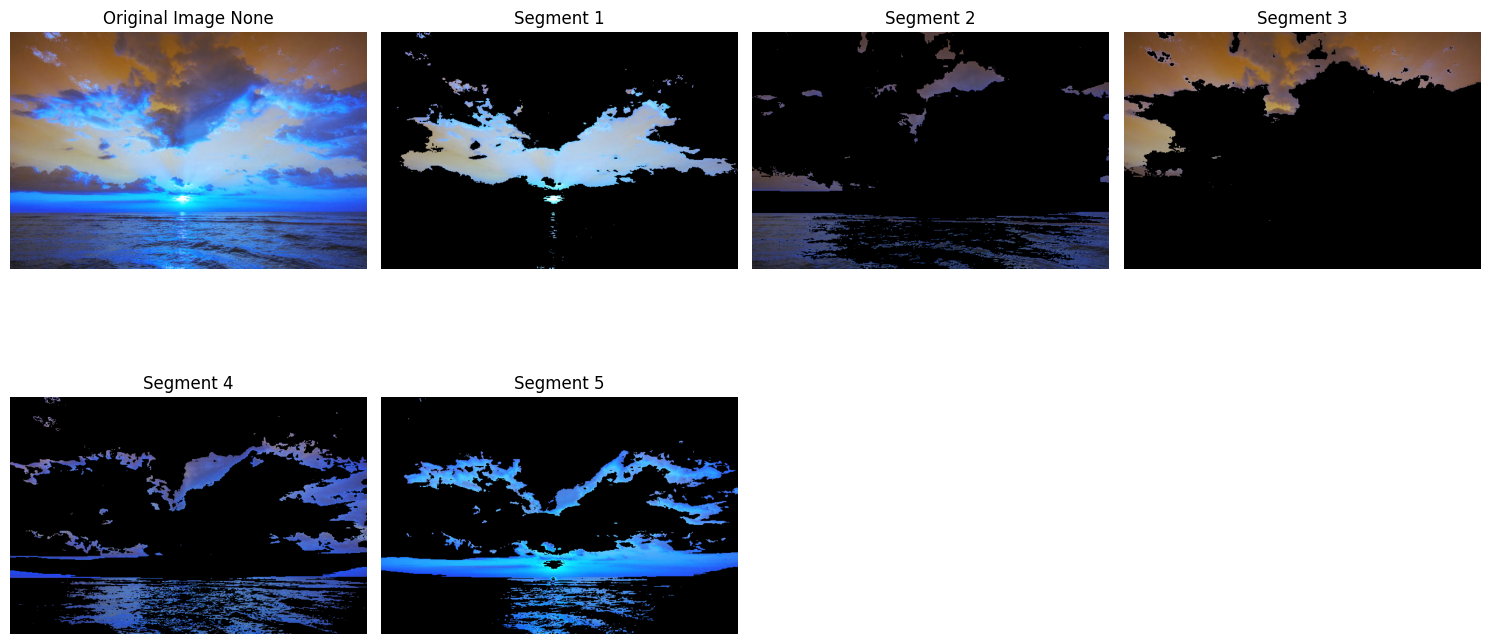

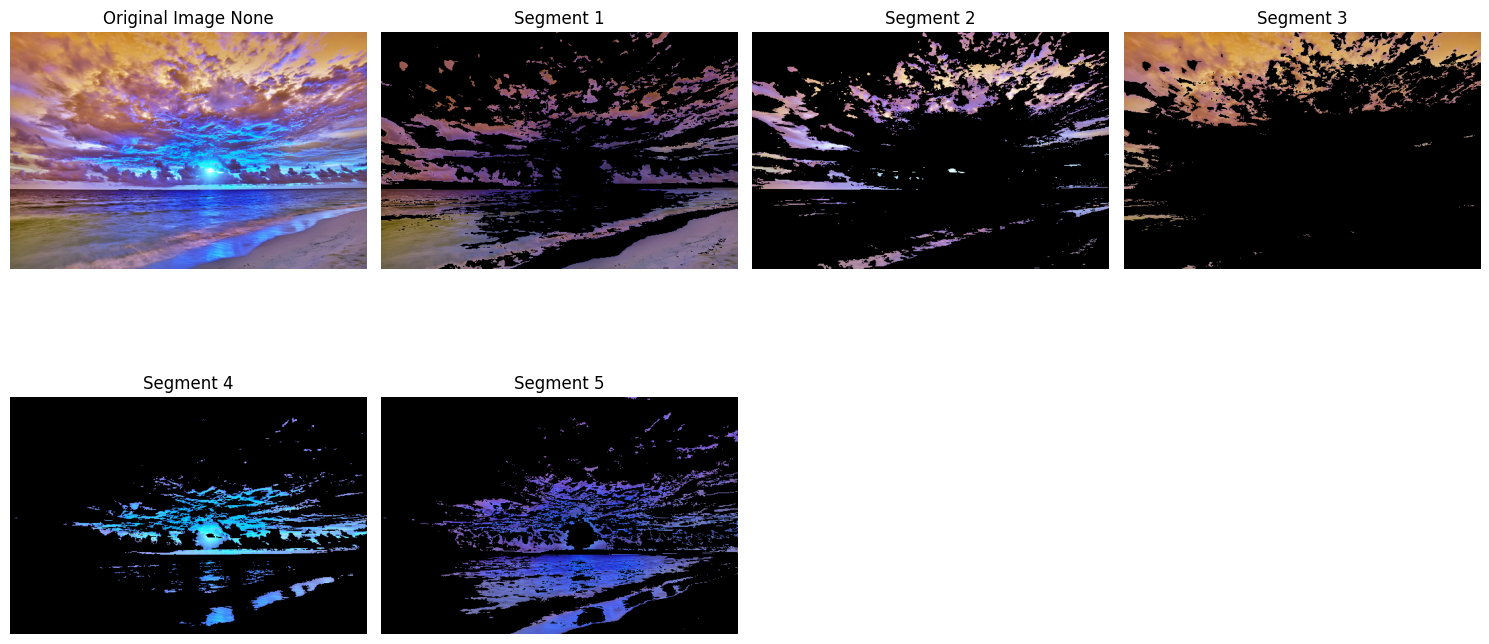

In [ ]:
dc2, pc2 = compute_and_display_segments(im2, k=5)
dc1, pc1 = compute_and_display_segments(im1, k=5)



In [ ]:
dc1

array([[118.16837761,  92.21003621, 120.58350343],
       [183.25838981, 151.10817536, 186.18567266],
       [ 99.13484758, 137.54971907, 194.079211  ],
       [246.21117507, 170.26069722,  86.71665943],
       [199.87440752,  93.1707444 ,  87.29209019]])

In [ ]:
dc2

array([[218.01341371, 188.72834453, 157.07162878],
       [101.35439752,  65.78340504,  62.52397664],
       [ 69.2874565 ,  93.33387607, 129.52319382],
       [182.57540054,  98.04854228,  71.52239054],
       [245.99054802, 148.18438037,  55.35165171]])

In [ ]:
import torch
distances = torch.cdist(torch.tensor(dc1), torch.tensor(dc2))

In [ ]:
distances

tensor([[143.5834,  65.9696,  49.7044,  81.1748, 154.0352],
        [ 58.9136, 171.1163, 139.7780, 126.3466, 145.1255],
        [134.6140, 149.8736,  83.7460, 153.4368, 202.2994],
        [ 78.0128, 180.2339, 197.6161,  97.4422,  38.3559],
        [119.7057, 105.2127, 137.2459,  23.9109,  78.5709]],
       dtype=torch.float64)

In [ ]:
find_combinations(distances.numpy(), 30)

{'A5': ['B4']}

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
def generate_patch(rgb, width=100, height=100):
    # Convert RGB to BGR (OpenCV uses BGR format)
    bgr = (rgb[2], rgb[1], rgb[0])

    # Create an image of the given color
    patch = np.full((height, width, 3), bgr, dtype=np.uint8)

    # Save the image
    cv2.imwrite("patch.png", patch)

    # Show the patch (optional)
    cv2_imshow(patch)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Example usage
#generate_patch((255, 0, 0))  # Generates a red patch


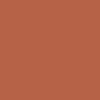

In [ ]:
generate_patch(dc2[3])

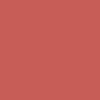

In [ ]:
generate_patch(dc1[4])